1. Install and import necessary libraries

In [3]:
%pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


2. Import and read the file

In [4]:
# Load the dataset
df = pd.read_csv('amazon.csv')

# Check structure and data types
print(df.info())

df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB
N

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


3. Data Cleaning

In [5]:
# Check for nulls & duplicates
print("Null Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Null Values:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

Duplicate Rows:
0


In [6]:
# Check how many row where rating contains "|"
pipe_count = (df['rating'] == '|').sum()
print(pipe_count)

# Remove row where rating contains "|" since there's only 1 of it
df = df.drop(df[df['rating'] == '|'].index)

1


In [7]:
# Remove symbols (currency, comma, percent, period)
df['actual_price'] = df['actual_price'].str.replace('₹','').str.replace(',','')
df['discounted_price'] = df['discounted_price'].str.replace('₹','').str.replace(',','')
df['rating_count'] = df['rating_count'].str.replace(',','')
df['discount_percentage'] = df['discount_percentage'].str.replace('%','')
df['rating'] = df['rating'].str.replace('.','')

# Convert to float
df['actual_price'] = df['actual_price'].astype(float)
df['discounted_price'] = df['discounted_price'].astype(float)
df['discount_percentage'] = df['discount_percentage'].astype(float)/100
df['rating'] = df['rating'].astype(float)/10

4. Segmentation

In [8]:
# Define thresholds based on discount_price
df['price_segment'] = pd.qcut(df['discounted_price'],q=3, labels=['Budget','Mid-Range','Premium'])

In [9]:
# Calculate Volume and Average Rating per segment
segment_analysis = df.groupby('price_segment').agg({
    'rating': 'mean',
    'rating_count':'sum',
    'product_id': 'count'
}).rename(columns={'product_id':'product_count'})

print(segment_analysis)

                 rating                                       rating_count  \
price_segment                                                                
Budget         3.998998  2426943994792894363169052487115188304114399413...   
Mid-Range      3.952823  1796918151843551355246212093813124780818817969...   
Premium        3.943710  3284011976162994703348997298271514003348997109...   

               product_count  
price_segment                 
Budget                   499  
Mid-Range                496  
Premium                  469  


5. Visualization

/tmp/ipykernel_2266/3501486392.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='price_segment', y='rating', data=df, palette='viridis')


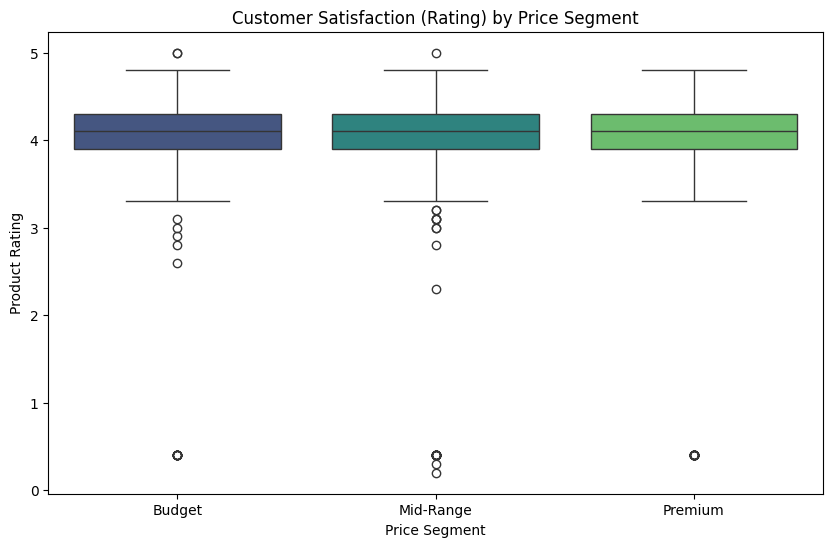

In [10]:
plt.figure(figsize=(10,6))
sns.boxplot(x='price_segment', y='rating', data=df, palette='viridis')

plt.title('Customer Satisfaction (Rating) by Price Segment')
plt.xlabel('Price Segment')
plt.ylabel('Product Rating')
plt.show()

In [44]:
# Filter for Mid-Range products with ratings equal or below 3.6
low_rated_mid = df[(df['price_segment'] == 'Mid-Range') & (df['rating'] <= 3.6)]

# Filter for Mid-Range products with ratings equal or above 4.0
high_rated_mid = df[(df['price_segment'] == 'Mid-Range') & (df['rating'] >= 4.0)]

In [ ]:
# Create a pivot table to find the lowest-rated categories
category_risk_mid = low_rated_mid.groupby('category').agg({
    'rating':'mean',
    'product_id':'count'
}).rename(columns={'rating':'avg_rating','product_id':'product_count'})

# Filter for categories with more than 3 products
# Sort by lowest rating first
return_risk_mid = category_risk_mid[category_risk_mid['product_count']>3].sort_values(by='avg_rating').head(5)

# Set display to show the full content of every cell
pd.set_option('display.max_colwidth',None)

print(return_risk_mid)

                                                                                                          avg_rating  \
category                                                                                                               
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|Kettles&HotWaterDispensers|Kettle&ToasterSets    1.640000   
Home&Kitchen|Heating,Cooling&AirQuality|RoomHeaters|FanHeaters                                              2.500000   
Home&Kitchen|Heating,Cooling&AirQuality|RoomHeaters|ElectricHeaters                                         2.775000   
Electronics|WearableTechnology|SmartWatches                                                                 3.225000   
Electronics|HomeTheater,TV&Video|Accessories|RemoteControls                                                 3.283333   

                                                                                                          product_count  
category                             

In [47]:
# Create a pivot table to find the highest-rated categories
category_strong_mid = high_rated_mid.groupby('category').agg({
    'rating':'mean',
    'product_id':'count'
}).rename(columns={'rating':'avg_rating','product_id':'product_count'})

# Filter category with more than 3 products
# Sort by the highest rating first
return_strong_mid = category_strong_mid[category_strong_mid['product_count']>3].sort_values(by='avg_rating',ascending=False).head(5)

# Set display to show the full content of every cell
pd.set_option('display.max_colwidth',None)

print(return_strong_mid)

                                                                                avg_rating  \
category                                                                                     
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Mice    4.414286   
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|EggBoilers             4.400000   
Electronics|Accessories|MemoryCards|MicroSD                                       4.388889   
Home&Kitchen|Heating,Cooling&AirQuality|RoomHeaters|FanHeaters                    4.340000   
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|HandBlenders           4.333333   

                                                                                product_count  
category                                                                                       
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Mice             14  
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppli